# NumPy for Array and Vectorized Computation

**Sources**

This notebook is a modification of chapter 4 in Python for Data Analysis, 3E.<br>
https://wesmckinney.com/book/

All the notebooks of this book are available at:<br>
https://github.com/wesm/pydata-book/tree/3rd-edition

**If you are a Colab user**

If you use Google Colab, uncomment the following cell to mount your Google Drive. After mounting, the notebook can read and write files in your Google Drive. Change the current directory to the folder where you saved this notebook and the data folder.


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

#%cd /content/drive/MyDrive/Colab\ Notebooks

**Import libraries and set up standards for the remainder of the notebook**

In [2]:
# import numpy
import numpy as np 

 # define the random seed for the random number generator
np.random.seed(12345)

# define printing style
np.set_printoptions(precision=4, suppress=True)

# import visualization module matplotlib.pyplot
import matplotlib.pyplot as plt 
# define figure size
plt.rc("figure", figsize=(10, 6)) 

# Display all outputs from each cell. Otherwise, only the last output is displayed
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## Efficiency of NumPy

One of the reasons NumPy is so important for numerical computations in Python is <br> because it is designed for efficiency on large arrays of data


In [3]:
# define an array and a list
my_arr = np.arange(1_000_000)
my_list = list(range(1_000_000))

#  use timeit to measure execution time. 
%timeit my_arr2 = my_arr * 2
%timeit my_list2 = [x * 2 for x in my_list]

642 μs ± 26.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
19.7 ms ± 374 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## The NumPy ndarray: A Multidimensional Array Object

One of the key features of NumPy is its N-dimensional array object, or ndarray,<br>
which is a fast, flexible container for large datasets in Python. <br>
Arrays enable us to perform mathematical operations on whole blocks of data <br>
using similar syntax to the equivalent operations between scalar elements.

In [4]:
# create an array

data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]])
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

In [5]:
# multiply all elements of the array by a number

data * 10

array([[ 15.,  -1.,  30.],
       [  0., -30.,  65.]])

In [6]:
# element-wise addition

data + data

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

In [7]:
# every array has a shape, a tuple indicating the size of each dimension
# this is an array of two rows and three columns. 
# here axis-0 is on the direction of rows and axis-y is on the direction of columns

# shape, an object describing the dimensions of the array
data.shape

(2, 3)

In [8]:
# An ndarray is a generic multidimensional container for homogeneous data; 
# that is, all of the elements must be the same type!

# dtype, an object describing the data type of the array
data.dtype

dtype('float64')

### Creating ndarrays

Table 4-1 has some important NumPy array creation functions. 
Here we introduce a few of them.

In [9]:
# The easiest way to create an array is to use the array function. This accepts any
# sequence-like object (including other arrays) and produces a new NumPy array
# containing the passed data

data1 = [6, 7.5, 8, 0, 1] # a list 
data1

arr1 = np.array(data1) # numpy.array() converts a list to an 1D array
arr1

[6, 7.5, 8, 0, 1]

array([6. , 7.5, 8. , 0. , 1. ])

In [10]:
data2 = [[1, 2, 3, 4], [5, 6, 7, 8]] # a list of two lists
data2

arr2 = np.array(data2)# # numpy.array() converts the list to a 2D array
arr2

[[1, 2, 3, 4], [5, 6, 7, 8]]

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [11]:
# ndim is a method to find the the number of dimensions of the array

arr2.ndim

2

In [12]:
# shape is a method to find the shape of the array

arr2.shape

(2, 4)

In [13]:
# check the data type using the dtype method

arr1.dtype

arr2.dtype

dtype('float64')

dtype('int64')

In [14]:
# The zeros method creates arrays of 0's

np.zeros(10)

np.zeros((3, 6))

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [15]:
#The ones method create an array of all ones
np.ones((3,1))

array([[1.],
       [1.],
       [1.]])

In [16]:
# the empty method creates an array without initializing its values to any particular value

np.empty((3,2))


np.empty((2, 3, 2))

array([[ 3. , -0.2],
       [ 6. ,  0. ],
       [-6. , 13. ]])

array([[[0., 0.],
        [0., 0.],
        [0., 0.]],

       [[0., 0.],
        [0., 0.],
        [0., 0.]]])

In [17]:
# the arange method is an array-valued version of the built-in Python range function

np.arange(15) 

np.arange(2,15,2)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

array([ 2,  4,  6,  8, 10, 12, 14])

### Data Types for ndarrays

Table 4-2 lists NumPy data types

The data type or dtype is a special object containing the information (or metadata, <br>
data about data) the ndarray needs to interpret a chunk of memory as a particular <br>
type of data

In [18]:
# claim data type when creating an array
arr1 = np.array([1, 2, 3], dtype=np.float64) # double-precision floating-point data
arr1.dtype

arr2 = np.array([1, 2, 3], dtype=np.int32) # 32-bit integer data
arr2.dtype

dtype('float64')

dtype('int32')

In [19]:
# We can explicitly convert or cast an array from one data type to another using
# ndarray’s astype method

#convert an array from 64-bit integer to double-precision floating-point data
arr = np.array([1, 2, 3, 4, 5])
arr
arr.dtype
float_arr = arr.astype(np.float64)
float_arr.dtype

print('\n')

# use the method astype() to convert an array of 64-bit float to 32-bit integer
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr
arr.dtype
arr.astype(np.int32)

print('\n')

# convert an array of strings to 64-bit float point
numeric_strings = np.array([1.25, -9.6, 42], dtype=np.str_)
numeric_strings
numeric_strings.dtype
numeric_strings.astype(np.float32)

array([1, 2, 3, 4, 5])

dtype('int64')

dtype('float64')

array([ 3.7, -1.2, -2.6,  0.5, 12.9, 10.1])

dtype('float64')

array([ 3, -1, -2,  0, 12, 10], dtype=int32)

array(['1.25', '-9.6', '42'], dtype='<U4')

dtype('<U4')

array([ 1.25, -9.6 , 42.  ], dtype=float32)

In [20]:
# we can apply the data type of an object to another object

# appy the data type of calibers to int_array
int_array = np.arange(10)
int_array

calibers = np.array([.22, .270, .357, .380, .44, .50], dtype=np.float64)
calibers

int_array.astype(calibers.dtype)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

array([0.22 , 0.27 , 0.357, 0.38 , 0.44 , 0.5  ])

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

### Arithmetic with NumPy Arrays

Arrays are important because they enable you to express batch operations on data without writing any for loops. 

NumPy users call this vectorization. Any arithmetic operations between equal-size arrays apply the operation element-wise

In [21]:
# define an array of size 2 x 3

arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [22]:
# element-wise multiplication

arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [23]:
# element-wise deduction

arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

In [24]:
# Arithmetic operations with scalars propagate the scalar argument to each element in the array

1 / arr

array([[1.    , 0.5   , 0.3333],
       [0.25  , 0.2   , 0.1667]])

In [25]:
# element-wise square

arr ** 2

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [26]:
# Comparisons between arrays of the same size yield Boolean arrays

arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])

print('arr2 is:\n',arr2)
print('arr is:\n',arr)
print('arr 2 > arr?')
arr2 > arr

arr2 is:
 [[ 0.  4.  1.]
 [ 7.  2. 12.]]
arr is:
 [[1. 2. 3.]
 [4. 5. 6.]]
arr 2 > arr?


array([[False,  True, False],
       [ True, False,  True]])

### Basic Indexing and Slicing

NumPy array indexing is a deep topic, as there are many ways you may want to select a subset of your data or <br> 
individual elements. One-dimensional arrays are simple. On the surface, they act similarly to Python lists.

In [27]:
# define an array

arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
# the element indexed as 5

arr[5]

np.int64(5)

In [29]:
# elements of arr indexed from 5 to 7

arr[5:8]

array([5, 6, 7])

In [30]:
# assign 12 to elements indexed from 5 to 7
arr[5:8] = 12
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

In [31]:
# An important first distinction from Python’s built-in lists is that
# array slices are views on the original array. This means that the data
# is not copied, and any modifications to the view will be reflected in
#the source array.

# for example, arr_slice is a slice of arr
arr_slice = arr[5:8]
arr_slice

# when we modify the arr_slice, a slice of arr, arr is modified too
arr_slice[1] = 12345
arr

# assign all elements of arr_slice as 64, which modifies the corresponding slice in arr
arr_slice[:] = 64
arr

array([12, 12, 12])

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

In [32]:
# If you want a copy of a slice of an ndarray instead of a view, you will need to 
# explicitly copy the array—for example, arr[5:8].copy()

# in this example, we copy a slice of arr to array_slice_nw. After we modify  array_slice_nw, 
# arry doesn't change

arr = np.arange(10)
array_slice_nw = arr[5:8].copy()
array_slice_nw 
array_slice_nw[:] = 64
array_slice_nw
arr

array([5, 6, 7])

array([64, 64, 64])

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [33]:
# define a 2D array
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [34]:
arr2d

# access the row indexed as 2
arr2d[2]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

array([7, 8, 9])

In [35]:
arr2d

# access the element indexed as row 0, column 2
arr2d[0][2]

# we can also pass a comma-separated list of indices to select individual elements
arr2d[0, 2]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

np.int64(3)

np.int64(3)

In [36]:
# In multidimensional arrays, if you omit later indices, the returned object will be a
# lower dimensional ndarray consisting of all the data along the higher dimensions

# define a 3D array
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d

# this example access the page with index 0
arr3d[0]

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

array([[1, 2, 3],
       [4, 5, 6]])

In [37]:
# again, array slices are views on the original array. The data is not copied, and any modifications 
# to the view will be reflected in the source array.

# save a copy of arr3d[0] as old_values
old_values = arr3d[0].copy() 
old_values

# modify arr3d[0] to be all 42's
arr3d[0] = 42
arr3d

# modify arr3d[0] by assigning the (original) values saved in old_values
arr3d[0] = old_values
arr3d

array([[1, 2, 3],
       [4, 5, 6]])

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [38]:
arr3d

# Similarly, arr3d[1, 0] gives you all of the values whose indices start with (1, 0)
arr3d[1, 0]

# This expression is the same as though we had indexed in two steps:
x = arr3d[1]
x[0]

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

array([7, 8, 9])

array([7, 8, 9])

Indexing with slices <br>
Like one-dimensional objects such as Python lists, ndarrays can be sliced with the
familiar syntax

Refer to Figure 4-2

In [39]:
arr = np.arange(10)
arr

arr[1:6]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

array([1, 2, 3, 4, 5])

In [40]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
arr2d

arr2d[:2]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

array([[1, 2, 3],
       [4, 5, 6]])

In [41]:
arr2d

# pass multiple slices just like you can pass multiple indexes
arr2d[:2, 1:]

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

array([[2, 3],
       [5, 6]])

In [42]:
arr2d

# By mixing integer indexes and slices, we get lower dimensional slices.
# Here, while arr2d is two-dimensional, lower_dim_slice is one-dimensional, and its
#shape is a tuple with one axis size:
lower_dim_slice = arr2d[1, :2]
lower_dim_slice
lower_dim_slice.shape

temp=arr2d[:2, 2]
temp
temp.shape

temp=arr2d[:, :1]
temp
temp.shape

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

array([4, 5])

(2,)

array([3, 6])

(2,)

array([[1],
       [4],
       [7]])

(3, 1)

In [43]:
arr2d
arr2d[:2, 1:]
arr2d[:2, 1:] = 0
arr2d

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

array([[2, 3],
       [5, 6]])

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

### Boolean Indexing

Boolean indexing is very helpful for identifying elements of interest. Here we illustrate a few examples.

In [44]:
# define a 1D array encompassing names. There are duplicated names
names = np.array(["Bob", "Joe", "Will", "Bob", "Will", "Joe", "Joe"])
names

# define a 2D array with the same size on axis-0 (i.e., the same number of rows)
data = np.array([[4, 7], 
                 [0, 2], 
                 [-5, 6], 
                 [0, 0], 
                 [1, 2],
                 [-12, -4], 
                 [3, 4]])
data

array(['Bob', 'Joe', 'Will', 'Bob', 'Will', 'Joe', 'Joe'], dtype='<U4')

array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [45]:
# Suppose each name corresponds to a row in the data array and we wanted to
# select all the rows with the corresponding name "Bob".
# comparisons (such as ==) with arrays are also vectorized. Thus, comparing names
# with the string "Bob" yields a Boolean array:
names == "Bob"

# This Boolean array can be passed when indexing the array:
data[names == "Bob"]

array([ True, False, False,  True, False, False, False])

array([[4, 7],
       [0, 0]])

In [46]:
# slices of data with axis-0= "Bob" and axis-1 = 1:
data[names == "Bob", 1:]

#access elements with axis-0 ="Bob", and axis-1=1
data[names == "Bob", 1]

array([[7],
       [0]])

array([7, 0])

In [47]:
# To select everything but "Bob" you can either use != or negate the condition using ~:

names != "Bob"

~(names == "Bob")

data[~(names == "Bob")]

array([False,  True,  True, False,  True,  True,  True])

array([False,  True,  True, False,  True,  True,  True])

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [48]:
# The ~ operator can be useful when you want to invert a Boolean array referenced by a variable

cond = names == "Bob"
data[~cond]

array([[  0,   2],
       [ -5,   6],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

In [49]:
# slice of data with names =="Bob" or "Will" 
#The Python keywords and and or do not work with Boolean arrays. Use & (and) and | (or) instead.
print('data:')
data

mask = (names == "Bob") | (names == "Will")
mask

print('data with True mask:')
data[mask]

data:


array([[  4,   7],
       [  0,   2],
       [ -5,   6],
       [  0,   0],
       [  1,   2],
       [-12,  -4],
       [  3,   4]])

array([ True, False,  True,  True,  True, False, False])

data with True mask:


array([[ 4,  7],
       [-5,  6],
       [ 0,  0],
       [ 1,  2]])

In [50]:
# find negative values of data, and change them to 0
# data<0 returns a boolean array indicating what elements of data are negative
# data[data < 0] = 0 assigns zeros to negative values of data

data[data < 0] = 0
data

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

In [51]:
# change all values of data to become 7 except for those pertaining to "Joe" 
data[names != "Joe"] = 7
data

array([[7, 7],
       [0, 2],
       [7, 7],
       [7, 7],
       [7, 7],
       [0, 0],
       [3, 4]])

### Fancy Indexing

Fancy indexing is a term adopted by NumPy to describe indexing using integer arrays

In [52]:
arr = np.zeros((8, 4))

for i in range(8):
    arr[i] = i
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [53]:
# To select a subset of the rows in a particular order, you can simply pass a list or
# ndarray of integers specifying the desired order:
arr

arr[[4, 3, 0, 6]]

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [0., 0., 0., 0.],
       [6., 6., 6., 6.]])

In [54]:
# Using negative indices selects rows from the end
arr[[-3, -5, -7]]

array([[5., 5., 5., 5.],
       [3., 3., 3., 3.],
       [1., 1., 1., 1.]])

In [55]:
# create an array of 32 elements, ranging from 0 to 31. Then reshape it according
# to the dimensions specified in the tuple
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [56]:
# selecting a subset of the matrix’s rows using arr[[1, 5, 7, 2]].
# Then, select a subset of columns from the subset. Here is one way to get that:
arr
arr[[1, 5, 7, 2]]
arr[[1, 5, 7, 2]][:, [0, 3, 1, 2]]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

array([[ 4,  5,  6,  7],
       [20, 21, 22, 23],
       [28, 29, 30, 31],
       [ 8,  9, 10, 11]])

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

In [57]:
# Keep in mind that fancy indexing, unlike slicing, always copies the data into a new
# array when assigning the result to a new variable. If you assign values with fancy
# indexing, the indexed values will be modified:
arr

arr[[1, 5, 7, 2], [0, 3, 1, 2]]

arr[[1, 5, 7, 2], [0, 3, 1, 2]] = 1000
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

array([ 4, 23, 29, 10])

array([[   0,    1,    2,    3],
       [1000,    5,    6,    7],
       [   8,    9, 1000,   11],
       [  12,   13,   14,   15],
       [  16,   17,   18,   19],
       [  20,   21,   22, 1000],
       [  24,   25,   26,   27],
       [  28, 1000,   30,   31]])

### Transposing Arrays and Swapping Axes

Transposing is a special form of reshaping that similarly returns a view on the underlying data without <br>
copying anything. Arrays have the transpose method and the special T attribute:

In [58]:
# the following example generates a 3x5 array. Then the transpose method changes it to a 5x3 array
arr = np.arange(15).reshape((3, 5))
arr
arr.T

np.transpose(arr) # np.transpose() is another way for transposing ndarray objects

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [59]:
# numpy.dot performs matrix computations

arr = np.array([[0, 1, 0], [1, 2, -2], [6, 3, 2], [-1, 0, -1], [1, 0, 1]])
arr
np.dot(arr.T, arr)

# np.matmul is another way to do matrix multiplication
np.matmul(arr.T, arr)

# The @ infix operator is another way to do matrix multiplication
arr.T @ arr

array([[ 0,  1,  0],
       [ 1,  2, -2],
       [ 6,  3,  2],
       [-1,  0, -1],
       [ 1,  0,  1]])

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

array([[39, 20, 12],
       [20, 14,  2],
       [12,  2, 10]])

In [60]:
#. ndarray has the method swapaxes, which takes a pair of axis numbers and switches the indicated axes to
# rearrange the data
# swapaxes similarly returns a view on the data without making a copy
arr
arr.swapaxes(0, 1)

array([[ 0,  1,  0],
       [ 1,  2, -2],
       [ 6,  3,  2],
       [-1,  0, -1],
       [ 1,  0,  1]])

array([[ 0,  1,  6, -1,  1],
       [ 1,  2,  3,  0,  0],
       [ 0, -2,  2, -1,  1]])

## Pseudorandom Number Generation

The numpy.random module supplements the built-in Python random module with functions for efficiently generating whole arrays of sample values from many kinds of probability distributions

Refer to Table 4-3

In [61]:
# generate a 4x4 array with all elements sampled from a standard normal distribution

samples = np.random.standard_normal(size=(4, 4))
samples

array([[-0.2047,  0.4789, -0.5194, -0.5557],
       [ 1.9658,  1.3934,  0.0929,  0.2817],
       [ 0.769 ,  1.2464,  1.0072, -1.2962],
       [ 0.275 ,  0.2289,  1.3529,  0.8864]])

In [62]:
#Python’s built-in random module, by contrast, samples only one value at a time. As
#you can see from this benchmark, numpy.random is well over an order of magnitude
#faster for generating very large samples

from random import normalvariate
N = 1_000_000
%timeit samples = [normalvariate(0, 1) for _ in range(N)]

%timeit np.random.standard_normal(N)

231 ms ± 1.01 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
11 ms ± 114 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [63]:
# These random numbers are not truly random (rather, pseudorandom) but instead
# are generated by a configurable random number generator that determines deterministically
# what values are created. Functions like numpy.random.standard_normal use
# the numpy.random module’s default random number generator, but our code can be
# configured to use an explicit generator

# default_rng() provides an object. The seed argument is what determines the initial state of the 
# generator, and the state changes each time the rng object is used to generate data

rng = np.random.default_rng(seed=12435)
data = rng.standard_normal((2, 3))
data

np.random.default_rng(seed=32).standard_normal((2,3))


array([[-1.6727,  0.1002, -0.8386],
       [ 0.0036,  0.8352, -0.0315]])

array([[ 0.9091,  0.7514, -0.0255],
       [ 0.6525, -0.651 , -1.8295]])

## Universal Functions: Fast Element-Wise Array Functions

A universal function, or ufunc, is a function that performs element-wise operations <br>
on data in ndarrays. You can think of them as fast vectorized wrappers for simple <br>
functions that take one or more scalar values and produce one or more scalar results <br>

Tables 4-4 and 4-5 are a listing of some of NumPy’s ufuncs

In [64]:
# unary ufuncs take one array as input, perform element-wise operation, and return one or multiple arrays of the same size
arr = np.arange(10)
arr

np.sqrt(arr)

np.exp(arr)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

array([0.    , 1.    , 1.4142, 1.7321, 2.    , 2.2361, 2.4495, 2.6458,
       2.8284, 3.    ])

array([   1.    ,    2.7183,    7.3891,   20.0855,   54.5982,  148.4132,
        403.4288, 1096.6332, 2980.958 , 8103.0839])

In [65]:
# binary ufuncs take two arrays as the input and return one array
# In this example, numpy.maximum computed the element-wise maximum of the elements in x and y.

x = rng.standard_normal(8)
y = rng.standard_normal(8)
print(x)
print(y)
np.maximum(x, y)

[-0.9771  0.223  -1.626  -1.1415 -0.4141 -0.0767  3.0634 -0.9082]
[ 2.9267  0.181   0.3912  0.0499  0.0038 -0.6224  0.3265  1.9499]


array([ 2.9267,  0.223 ,  0.3912,  0.0499,  0.0038, -0.0767,  3.0634,
        1.9499])

In [66]:
# a ufunc can return multiple arrays. numpy.modf is one example. 
# it returns the fractional and integral parts of a floating-point array
arr = rng.standard_normal(7) * 5
arr

remainder, whole_part = np.modf(arr)

print(f'whole part is: {whole_part}')
print(f'remainder is: {remainder}')

array([-1.0376, -9.5721, -0.8854, -9.0779, -1.8555,  3.7049,  0.2789])

whole part is: [-1. -9. -0. -9. -1.  3.  0.]
remainder is: [-0.0376 -0.5721 -0.8854 -0.0779 -0.8555  0.7049  0.2789]


In [67]:
# Ufuncs accept an optional out argument that allows them to assign their results into
# an existing array rather than create a new one
arr

# np.zeros_like() return an array of zeros with the same shape and type as a given array
out1 = np.zeros_like(arr) 
out1

#element-wise addition, with the resulting sum stored in out1
np.add(arr, 1, out=out1)
out1

array([-1.0376, -9.5721, -0.8854, -9.0779, -1.8555,  3.7049,  0.2789])

array([0., 0., 0., 0., 0., 0., 0.])

array([-0.0376, -8.5721,  0.1146, -8.0779, -0.8555,  4.7049,  1.2789])

array([-0.0376, -8.5721,  0.1146, -8.0779, -0.8555,  4.7049,  1.2789])

## Array-Oriented Programming with Arrays

Using NumPy arrays enables you to express many kinds of data processing <br> 
tasks as concise array expressions that might otherwise require writing loops. <br>
This practice of replacing explicit loops with array expressions is referred to <br>
by some people as vectorization. In general, vectorized array operations will <br>
usually be significantly faster than their pure Python equivalents, with the biggest <br>
impact in any kind of numerical computations.

In [68]:
# generate a grid 
points = np.arange(-5, 5, 0.01) # 100 equally spaced points 
xs, ys = np.meshgrid(points, points) # Return a list of coordinate matrices from coordinate vectors.
xs
ys

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]],
      shape=(1000, 1000))

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]],
      shape=(1000, 1000))

In [69]:
# evaluate the function sqrt(x^2 + y^2) across a regular grid of values.
z = np.sqrt(xs ** 2 + ys ** 2)
z

array([[7.0711, 7.064 , 7.0569, ..., 7.0499, 7.0569, 7.064 ],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       ...,
       [7.0499, 7.0428, 7.0357, ..., 7.0286, 7.0357, 7.0428],
       [7.0569, 7.0499, 7.0428, ..., 7.0357, 7.0428, 7.0499],
       [7.064 , 7.0569, 7.0499, ..., 7.0428, 7.0499, 7.0569]],
      shape=(1000, 1000))

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

Text(0.5, 0, 'x')

Text(0, 0.5, 'y')

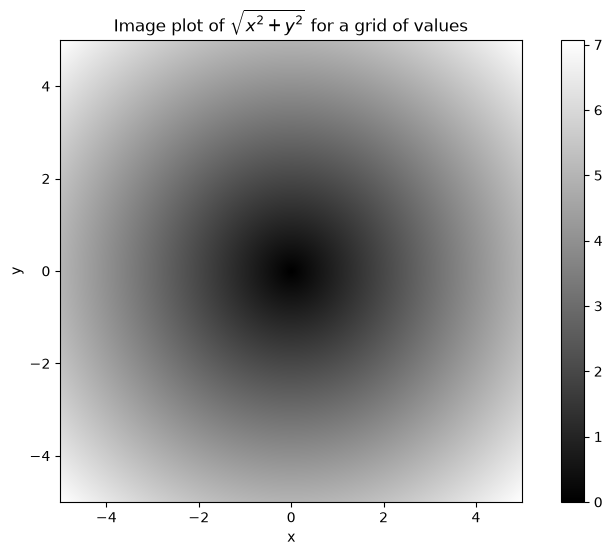

In [70]:
#Visualize the result as a grey color image

import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray, extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")
plt.xlabel('x')
plt.ylabel('y')
plt.draw()

# If you’re working in IPython, you can close all open plot windows by executing
#plt.close("all")

### Expressing Conditional Logic as Array Operations

In [71]:
# Suppose we had a Boolean array and two arrays of values
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

#Suppose we wanted to take a value from xarr whenever the corresponding value in
#cond is True, and otherwise take the value from yarr.
result = [(x if c else y)
          for x, y, c in zip(xarr, yarr, cond)]
result

# The numpy.where function is a vectorized version of the ternary expression x if condition else y
result = np.where(cond, xarr, yarr)
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

array([1.1, 2.2, 1.3, 1.4, 2.5])

In [72]:
# The second and third arguments to numpy.where don’t need to be arrays; one or
# both of them can be scalars. A typical use of where in data analysis is to produce a
# new array of values based on another array.

# In this example, arr is a 4x4 2D array with values drawn from the standard normal distribution
# A new 3D array is created by replacing all positive values with 2 and rest with -2  

arr = rng.standard_normal((4, 4))
arr

np.where(arr > 0, 2, -2)

array([[-0.2128, -1.4526,  1.2031,  1.2146],
       [-1.8153, -0.8487,  0.8216, -2.0293],
       [-1.8069,  1.651 ,  0.8462, -0.1245],
       [-0.5554,  2.6014, -1.9987,  0.7861]])

array([[-2, -2,  2,  2],
       [-2, -2,  2, -2],
       [-2,  2,  2, -2],
       [-2,  2, -2,  2]])

In [73]:
# only replace the positive values with 2 and rest unchanged
np.where(arr > 0, 2, arr) # set only positive values to 2

array([[-0.2128, -1.4526,  2.    ,  2.    ],
       [-1.8153, -0.8487,  2.    , -2.0293],
       [-1.8069,  2.    ,  2.    , -0.1245],
       [-0.5554,  2.    , -1.9987,  2.    ]])

### Mathematical and Statistical Methods

A set of mathematical functions that compute statistics about an entire array or
about the data along an axis are accessible as methods of the array class. We can
use aggregations (sometimes called reductions) like sum, mean, and std (standard
deviation) either by calling the array instance method or using the top-level NumPy
function. Here we illustrate a few examples.

Table 4-6. Basic array statistical methods

In [74]:
# generate a 5x4 2D array
arr = rng.standard_normal((5, 4))
arr

array([[ 1.2933, -0.5865, -1.8037, -1.4682],
       [ 0.7244,  0.3784, -0.4763, -0.3907],
       [-0.1153, -0.3601,  0.0734, -0.0078],
       [ 1.1036,  0.6181, -0.1624, -0.8666],
       [ 1.9346, -1.074 ,  1.1095,  0.4978]])

In [75]:
# use the mean method to calculate the mean value by calling the array instance
arr.mean()

# calculate mean along axis-1 (e.g., mean values by rows)
arr.mean(axis=1)

# calculate mean along axis-0 (e.g., means by columns)
arr.sum(axis=0)

np.float64(0.021077779016791143)

array([-0.6413,  0.059 , -0.1025,  0.1732,  0.617 ])

array([ 4.9406, -1.0241, -1.2596, -2.2354])

In [76]:
# When we use the NumPy function, we have to pass the array we want to average 
# as the first argument.
np.mean(arr)

np.float64(0.021077779016791143)

In [77]:
# cumsum and cumprod do not aggregate. It calculates the cumulative values up to

# cumsum return the cumulative sum of the elements along a given axis. 
arr = np.arange(8)
arr
arr.cumsum()

# cumprod return the cumulative product of the elements along a given axis. 
arr = np.arange(1,9)
arr
arr.cumprod()

array([0, 1, 2, 3, 4, 5, 6, 7])

array([ 0,  1,  3,  6, 10, 15, 21, 28])

array([1, 2, 3, 4, 5, 6, 7, 8])

array([    1,     2,     6,    24,   120,   720,  5040, 40320])

In [78]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
arr

# cumsum along axis=0 
arr.cumsum(axis=0)

# cumsum along axis=1
arr.cumsum(axis=1)

# The default (None) is to compute the cumsum over the flattened array.
arr.cumsum()

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])

array([[ 0,  1,  3],
       [ 3,  7, 12],
       [ 6, 13, 21]])

array([ 0,  1,  3,  6, 10, 15, 21, 28, 36])

### Methods for Boolean Arrays

sum, any, and all are commonly used methods for analyzing boolean arrays

In [79]:
# sum is often used as a means of counting True values in a Boolean array
arr = rng.standard_normal(100)
(arr > 0).sum() # Number of positive values
(arr <= 0).sum() # Number of non-positive values

np.int64(50)

np.int64(50)

In [80]:
bools = np.array([False, False, True, False])

# any tests whether one or more values in an array is True
bools.any()

# all checks if every value is True
bools.all()

np.True_

np.False_

### Sorting

NumPy arrays can be sorted in place with the sort method

In [81]:
# calling the sort method to sort an array's element from the smallest to the largest
arr = rng.standard_normal(6)
arr

arr.sort()
arr

# reverse the sorted array letting the step be -1
arr[::-1]

array([-0.9331,  0.0083, -1.1456,  1.6744,  0.2927, -1.1726])

array([-1.1726, -1.1456, -0.9331,  0.0083,  0.2927,  1.6744])

array([ 1.6744,  0.2927,  0.0083, -0.9331, -1.1456, -1.1726])

In [82]:
# sort each one-dimensional section of values in a multidimensional 
# array in place along an axis by passing the axis number to sort

# create a 2D array
arr = rng.standard_normal((5, 3))
arr

# sort along axis=0
arr.sort(axis=0)
arr

# sort along axis=1
arr.sort(axis=1)
arr

array([[ 0.1579, -0.8821, -0.3571],
       [-0.378 , -0.8799, -1.2146],
       [ 0.7223,  0.7684, -0.0175],
       [-2.7295,  1.594 , -1.0431],
       [-1.8604,  0.9036, -0.6873]])

array([[-2.7295, -0.8821, -1.2146],
       [-1.8604, -0.8799, -1.0431],
       [-0.378 ,  0.7684, -0.6873],
       [ 0.1579,  0.9036, -0.3571],
       [ 0.7223,  1.594 , -0.0175]])

array([[-2.7295, -1.2146, -0.8821],
       [-1.8604, -1.0431, -0.8799],
       [-0.6873, -0.378 ,  0.7684],
       [-0.3571,  0.1579,  0.9036],
       [-0.0175,  0.7223,  1.594 ]])

In [83]:
# The top-level method numpy.sort returns a sorted copy of an array (like the Python
# built-in function sorted) instead of modifying the array in place.

arr2 = np.array([5, -10, 7, 1, 0, -3])
sorted_arr2 = np.sort(arr2)

sorted_arr2
arr2

array([-10,  -3,   0,   1,   5,   7])

array([  5, -10,   7,   1,   0,  -3])

### Unique and Other Set Logic

NumPy has some basic set operations for one-dimensional ndarrays. Here we illustrate a few examples.

Table 4-7. Array set operations

In [84]:
# numpy.unique returns the sorted unique values in an array

names = np.array(["Bob", "Will", "Joe", "Bob", "Will", "Joe", "Joe"])
np.unique(names)

ints = np.array([3, 3, 3, 2, 2, 1, 1, 4, 4])
np.unique(ints)

array(['Bob', 'Joe', 'Will'], dtype='<U4')

array([1, 2, 3, 4])

In [85]:
# Contrast numpy.unique with the pure Python alternative:

sorted(set(names))

[np.str_('Bob'), np.str_('Joe'), np.str_('Will')]

In [86]:
# numpy.isin tests membership of the values in one array in another, returning a Boolean array

values = np.array([6, 0, 0, 3, 2, 5, 6])
np.isin(values, [2, 3, 6])

array([ True, False, False,  True,  True, False,  True])

In [87]:
arr_1= ([1,5,3,2])
arr_2=([2,7,3,5,4])

arr_1
arr_2

# numpy.intersect1d(x,y) computes the sorted, common elements in x and y
np.intersect1d(arr_1, arr_2)

# union1d(x, y) computes the sorted union of elements in x and y
np.union1d(arr_1, arr_2) 

# setdiff1d(x, y) computes set difference, elements in x that are not in y
np.setdiff1d(arr_1, arr_2) 
np.setdiff1d(arr_2, arr_1) 

# setxor1d(x, y) computes set symmetric differences; elements that are in either of the arrays, but not both
np.setxor1d(arr_1, arr_2)

[1, 5, 3, 2]

[2, 7, 3, 5, 4]

array([2, 3, 5])

array([1, 2, 3, 4, 5, 7])

array([1])

array([4, 7])

array([1, 4, 7])